In [13]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

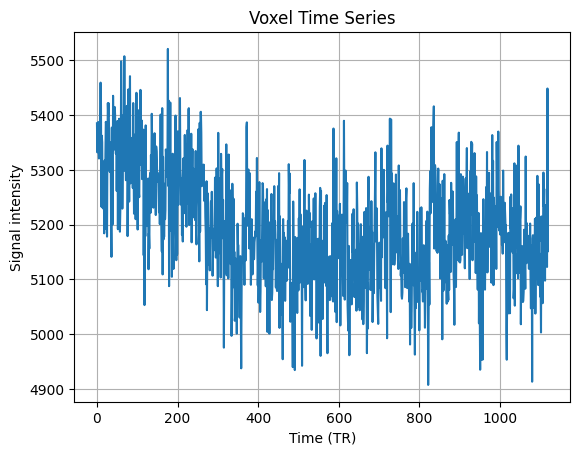

In [14]:
# Load BOLD (volume)
img = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/func/sub-01_ses-15_task-RestingState_dir-pa_space-fsLR_den-91k_bold.dtseries.nii')
data = img.get_fdata()  # shape: X x Y x Z x T

# Pick a voxel (e.g., center of brain)
voxel_ts = data[:, 100]  # adjust to actual GM

# Plot
plt.plot(voxel_ts)
plt.title("Voxel Time Series")
plt.xlabel("Time (TR)")
plt.ylabel("Signal intensity")
plt.grid(True)
plt.show()

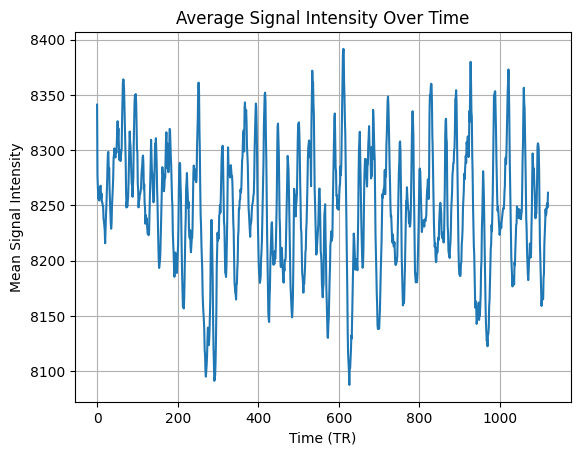

In [15]:
# Calculate the mean signal intensity across all voxels for each time point
mean_signal = np.mean(data, axis=1)

# Plot the average trend over time
plt.plot(mean_signal)
plt.title("Average Signal Intensity Over Time")
plt.xlabel("Time (TR)")
plt.ylabel("Mean Signal Intensity")
plt.grid(True)
plt.show()

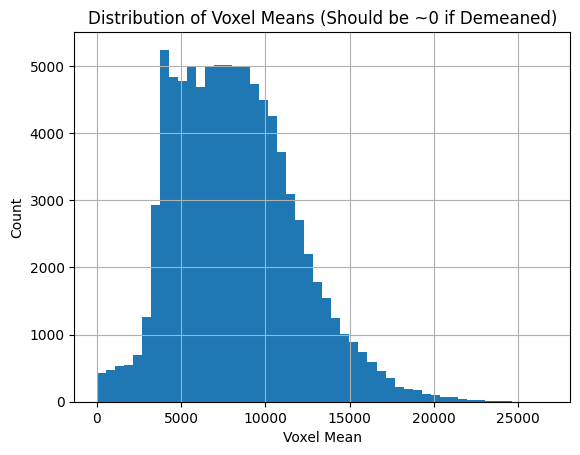

Mean of voxel means: 8245.920844573258
Std of voxel means: 3606.170036405976


In [16]:
# Check if data is demeaned: mean across time for each voxel
voxel_means = np.mean(data, axis=0)

plt.hist(voxel_means, bins=50)
plt.title("Distribution of Voxel Means (Should be ~0 if Demeaned)")
plt.xlabel("Voxel Mean")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Optionally, print the overall mean and standard deviation
print("Mean of voxel means:", np.mean(voxel_means))
print("Std of voxel means:", np.std(voxel_means))
# ...existing code...

## Check Nifti

In [26]:
# Load the specified NIfTI file with 91k vertices
demean_detrend = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_demean_detrend.dtseries.nii')
detrended_nomw = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_detrended_nomw.dtseries.nii')
before_l = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_L.func.gii')
nomw_l = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_L.nomw.func.gii')
subcortical = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_subcort.nii.gz')

# Get the data from the file
demean_detrend = demean_detrend.get_fdata()
detrended_nomw = detrended_nomw.get_fdata()
befire_l = before_l.darrays[0].data
nomw_l = nomw_l.darrays[0].data
subcortical_data = subcortical.get_fdata()

# Print basic information about the data
print("Shape of the data before:", demean_detrend.shape)
print("Shape of the data after:", detrended_nomw.shape)
print("Shape of the left hemisphere before:", befire_l.shape)
print("Shape of the left hemisphere after:", nomw_l.shape)
print("Shape of the subcortical data:", subcortical_data.shape)

Shape of the data before: (1120, 91282)
Shape of the data after: (1120, 96854)
Shape of the left hemisphere before: (32492,)
Shape of the left hemisphere after: (32492,)
Shape of the subcortical data: (55, 60, 50, 1120)


Shape of the data before: (1120, 91282)
Data type: float64
Shape of the data after: (1120, 59412)
Data type after processing: float64


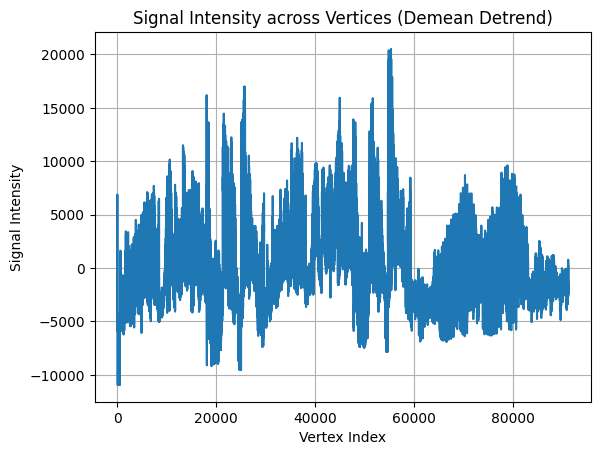

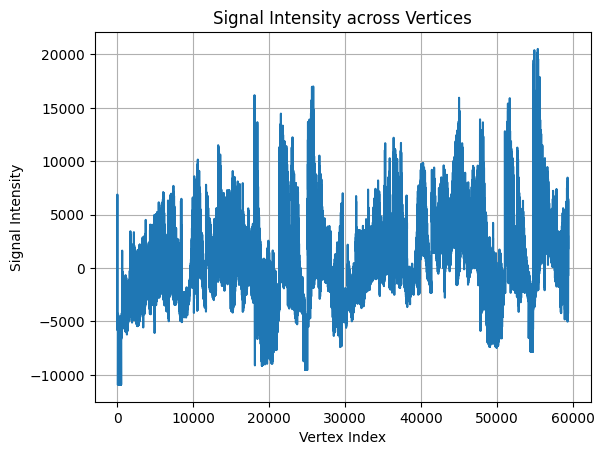

ValueError: operands could not be broadcast together with shapes (1120,91282) (1120,59412) 

In [ ]:
# Load the specified NIfTI file with 91k vertices
demean_detrend = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_demean_detrend.dtseries.nii')
detrended_nomw = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_detrended_nomw.dtseries.nii')

# Get the data from the file
demean_detrend = demean_detrend.get_fdata()
detrended_nomw = detrended_nomw.get_fdata()

# Print basic information about the data
print("Shape of the data before:", demean_detrend.shape)
print("Data type:", demean_detrend.dtype)
print("Shape of the data after:", detrended_nomw.shape)
print("Data type after processing:", detrended_nomw.dtype)

# If it's a time series, visualize the time series for a specific vertex/voxel
if len(demean_detrend.shape) == 2:  # Typically (time, vertices/voxels)
    plt.plot(demean_detrend[0, :])  # Plot the signal intensity for the first time point across all vertices
    plt.title("Signal Intensity across Vertices (Demean Detrend)")
    plt.xlabel("Vertex Index")
    plt.ylabel("Signal Intensity")
    plt.grid(True)
    plt.show()
else:
    print("Unexpected data shape. Visualization may need adjustment.")

if len(detrended_nomw.shape) == 2:  # Typically (time, vertices/voxels)
    plt.plot(detrended_nomw[0, :])  # Plot the signal intensity for the first time point across all vertices
    plt.title("Signal Intensity across Vertices")
    plt.xlabel("Vertex Index")
    plt.ylabel("Signal Intensity")
    plt.grid(True)
    plt.show()
else:
    print("Unexpected data shape. Visualization may need adjustment.")

# Print which voxels differ from demean_detrend and detrended_nomw
diff_voxels = np.where(demean_detrend != detrended_nomw)
print("Indices of differing voxels:", diff_voxels)

In [29]:
import nibabel as nib
img = nib.load("/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_detrended_nomw.dtseries.nii")
print(img.get_fdata().shape)
print(img.header.matrix.get_index_map(1).number_of_rows)

(1120, 91282)


AttributeError: 'Cifti2MatrixIndicesMap' object has no attribute 'number_of_rows'

In [11]:
# Load the specified NIfTI file with medial wall removed
nifti_file = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_subcort.nii.gz')

# Get the data from the file
nifti_data = nifti_file.get_fdata()

# Print basic information about the data
print("Shape of the CIFTI-2 data:", nifti_data.shape)
print("Data type:", nifti_data.dtype)

# If it's a time series, visualize the time series for a specific vertex/voxel
if len(nifti_data.shape) == 2:  # Typically (time, vertices/voxels)
    plt.plot(nifti_data[0, :])  # Plot the signal intensity for the first time point across all vertices
    plt.title("Signal Intensity across Vertices")
    plt.xlabel("Vertex Index")
    plt.ylabel("Signal Intensity")
    plt.grid(True)
    plt.show()
else:
    print("Unexpected data shape. Visualization may need adjustment.")

Shape of the CIFTI-2 data: (91, 109, 91, 1120)
Data type: float64
Unexpected data shape. Visualization may need adjustment.


## Check Data Type

In [12]:
import nibabel as nib
img = nib.load("/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_subcort.nii.gz")
print(f"Data type: {img.get_data_dtype()}")

Data type: float32
